# Quantum Benchmark Toolkit — Exploration

Interactive notebook for inspecting circuits, running quick experiments, and visualizing results.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Build and inspect circuits

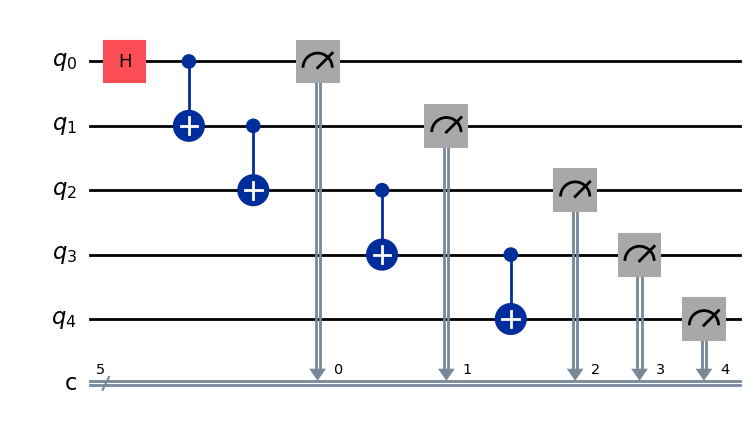

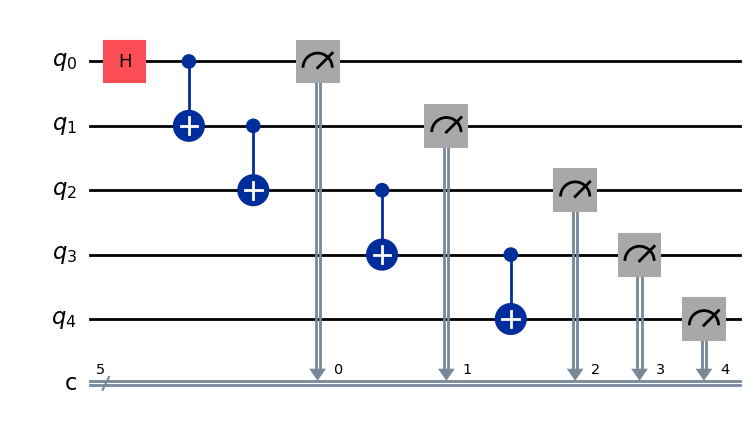

In [2]:
from circuits.ghz import build_ghz
qc = build_ghz(5)
qc.draw('mpl')

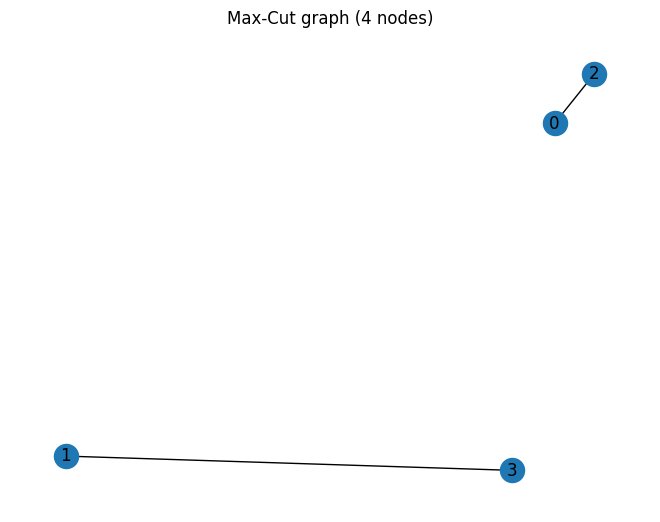

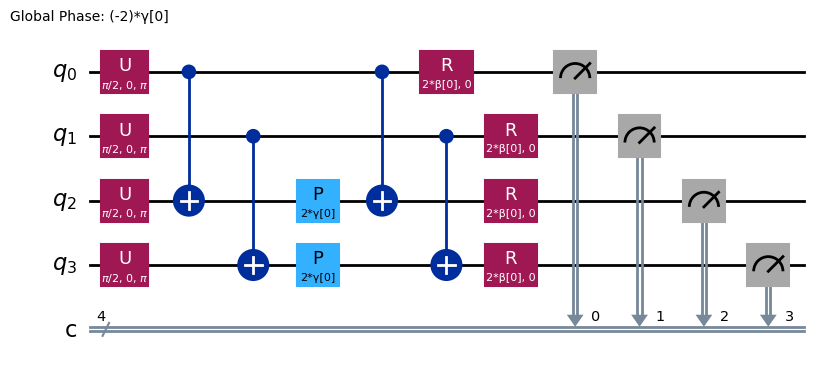

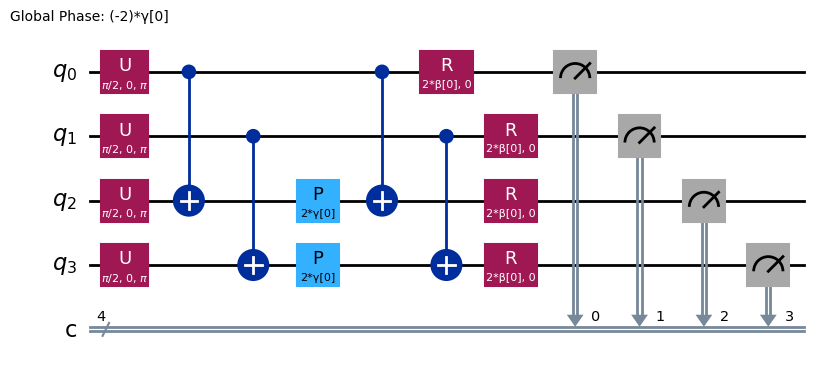

In [3]:
from circuits.qaoa import build_maxcut_graph, build_qaoa
import networkx as nx

G = build_maxcut_graph(4, seed=42)
nx.draw(G, with_labels=True)
plt.title('Max-Cut graph (4 nodes)')
plt.show()

qaoa_qc = build_qaoa(G, p=1)
qaoa_qc.decompose().draw('mpl')

## 2. Transpile for different backends and compare metrics

In [4]:
from backends.qiskit_backends import get_ideal_simulator, get_fake_backend, transpile_circuit, circuit_metrics

ghz5 = build_ghz(5)
results = []
for backend_name in ['ideal_simulator', 'fake_nairobi', 'fake_lagos']:
    if backend_name == 'ideal_simulator':
        be = get_ideal_simulator()
    else:
        be = get_fake_backend(backend_name)
    for opt in range(4):
        tr = transpile_circuit(ghz5, be, opt)
        m = circuit_metrics(tr)
        results.append({'backend': backend_name, 'opt_level': opt, **m})

df = pd.DataFrame(results)
df[['backend', 'opt_level', 'depth', 'two_qubit_gate_count', 'gate_count']]

,backend,opt_level,depth,two_qubit_gate_count,gate_count
0,ideal_simulator,0,6,4,10
1,ideal_simulator,1,6,4,10
2,ideal_simulator,2,6,4,10
3,ideal_simulator,3,6,4,10
4,fake_nairobi,0,11,10,18
5,fake_nairobi,1,8,4,12
6,fake_nairobi,2,8,4,12
7,fake_nairobi,3,8,4,12
8,fake_lagos,0,14,13,21
9,fake_lagos,1,8,4,12


## 3. Run a quick GHZ benchmark

In [5]:
from runners.run_qiskit import run_qiskit_ghz

row = run_qiskit_ghz(build_ghz(5), n_qubits=5, backend_name='ideal_simulator', opt_level=1, shots=1024)
print(f"Depth: {row['depth']}, Quality: {row['quality_score']:.3f}")

from analysis.plots import plot_output_distribution
plot_output_distribution(row['counts'], title='GHZ-5 ideal simulator', name='ghz5_ideal')
plt.show()

Depth: 6, Quality: 1.000


## 4. Load and plot saved results

In [6]:
import glob
csv_files = sorted(glob.glob('../results/processed/*.csv'))
if csv_files:
    df = pd.read_csv(csv_files[-1])
    print(df.head())

    from analysis.plots import generate_all_plots
    generate_all_plots(df)
    print('Plots saved to results/processed/')
else:
    print('No results yet. Run: python scripts/run_experiment.py')

  workload  n_qubits          backend  opt_level  shots  transpile_time_s  \
0      ghz         3  ideal_simulator          0   1024          0.227421   
1      ghz         3  ideal_simulator          1   1024          0.040450   
2      ghz         3  ideal_simulator          2   1024          0.040975   
3      ghz         3  ideal_simulator          3   1024          0.039804   
4      ghz         3     fake_nairobi          0   1024          0.002652   

   runtime_s  depth  gate_count  two_qubit_gate_count  quality_score  
0   0.002159      4           6                     2        1.00000  
1   0.001122      4           6                     2        1.00000  
2   0.000952      4           6                     2        1.00000  
3   0.001037      4           6                     2        1.00000  
4   0.009186      6           8                     2        0.90918  
Plots saved to results/processed/
